In [4]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

In [5]:
api = wandb.Api()

In [6]:
EXPERIMENT_GROUP = "tmp/imagenet-run2"

In [18]:
def read_data(
    teacher,
    student,
    arr_policies,
#     basis_name,
    lambda_task,
    lambda_layer,
    dataset,
    training_size,
    verbose=False,
    
):
    
    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_layer": {"$in": [lambda_layer]}},
            {"config.policy": {"$in": arr_policies}},
            {"config.training_size": training_size},
            {"config.dataset": dataset},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    for run in runs:
        seed = run.config["seed"]
         
        
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]


        rows.append(
            dict(
                seed=seed,
                policy=run.config["policy"],
                lambda_kd=run.config["lambda_kd"],
                lambda_layer=run.config["lambda_layer"],
                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"]
            )
        )

    
    df = pd.DataFrame(rows)
        
    df = df.groupby(by="policy").agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="imagenet-resnet18-tv",
    student="resnet18imagenetcompr2",
    arr_policies=["basis:pca", "basis:random"],
    lambda_task=0.0,
    lambda_layer=0.5,
    training_size=0.1,
    verbose=True,
    dataset="imagenet-butterfly",
)

summary

we have 2 runs
df.shape: (2, 11)


policy   val_acc           val_agreement            \
                     mean std count          mean std count   
0     basis:pca  0.886667 NaN     1      0.896667 NaN     1   
1  basis:random  0.883333 NaN     1      0.896667 NaN     1   

  val_agreement_on_teacher_correct           teacher_acc  
                              mean std count        mean  
0                             0.88 NaN     1    0.966667  
1                             0.88 NaN     1    0.966667

# Comparison on `cifar100-resnet18-wb15`

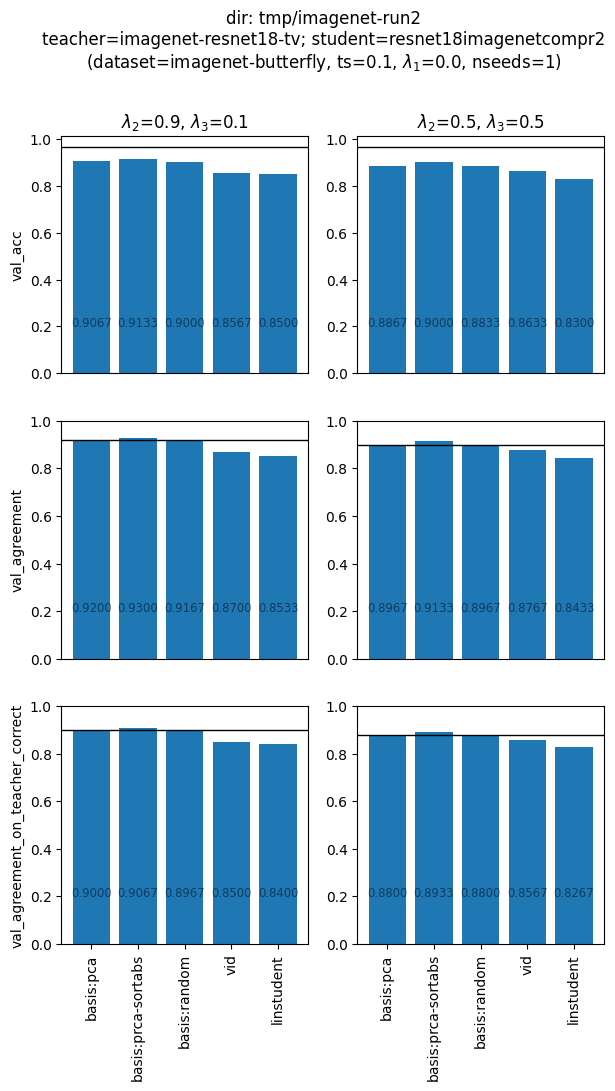

In [33]:
def ls(basis_name):
    if "random" in basis_name:
        return ":"
    elif basis_name == "linstudent":
        return "--"
    else:
        return "-"
    
def color(basis_name):
    if "random" in basis_name:
        return "gray"
    else:
        return None
    
def viz_distillation(teacher, student, training_size, arr_lambda_layers):
        
    dataset = "imagenet-butterfly"
    lambda_task = 0.0
    
    policies = [ 
        "basis:pca",
        "basis:prca-sortabs",
        "basis:random",
        "vid",
        "linstudent"
    ]
        
    columns = ["val_acc", "val_agreement", "val_agreement_on_teacher_correct"]

    
    ncols = len(arr_lambda_layers)
    nrows = len(columns)
    
    plt.figure(figsize=(3.5*ncols, 3.5*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])

    
    ticks = list(range(len(policies)))
    
    for aix, lambda_layer in enumerate(arr_lambda_layers):
        for cix, col in enumerate(columns):
            df = read_data(
                teacher=teacher,
                student=student,
                lambda_task=lambda_task,
                lambda_layer=lambda_layer,
                arr_policies=policies,
                dataset=dataset,
                training_size=training_size,
            )

            plt.subplot(nrows, ncols, aix + cix * ncols + 1)
            count = -1
            if aix == 0:
                plt.ylabel(col)
            
            if cix == 0:
                plt.title(f"$\lambda_2$={1-lambda_layer}, $\lambda_3$={lambda_layer}")

            if cix == nrows - 1:
                plt.xticks(
                    ticks,
                    policies,
                    rotation=90
                )
            else:
                plt.xticks([])
            
            count = df[col]["count"][0]
            
            values =  df[col]["mean"]
            if col == "val_acc":
                plt.axhline(df["teacher_acc"]["mean"][0], ls="-", color="k", lw=1)
            else:
                plt.axhline(values[0], ls="-", color="k", lw=1)
                plt.ylim(top=1.0)

            plt.bar(ticks, values)
            
            for t, v in zip(ticks, values):
                plt.text(t, 0.2, f"{v:.4f}", alpha=0.5, ha="center", fontsize="small")
            


    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            f"teacher={teacher}; student={student}",
            f"(dataset={dataset}, ts={training_size}, $\lambda_1$={lambda_task}, nseeds={count})",
        ]),
        y=1.0
    )

viz_distillation(
    teacher = "imagenet-resnet18-tv",
    student="resnet18imagenetcompr2",
    training_size=0.1,
    arr_lambda_layers=[0.1, 0.5]
) 

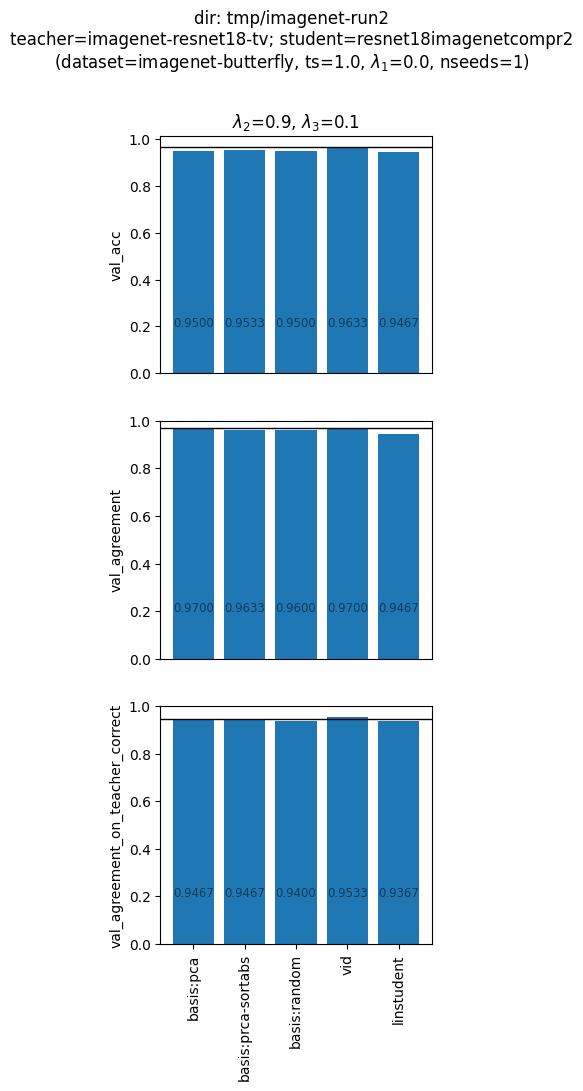

In [34]:
viz_distillation(
    teacher = "imagenet-resnet18-tv",
    student="resnet18imagenetcompr2",
    training_size=1.0,
    arr_lambda_layers=[0.1]
) 

# Summary

Dataset: `imagenet-butterfly` (`trainining_size={0.1, 1.0}`)

Setup:
$$
 (0.0) \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer},
$$
$\lambda_2 = 1- \alpha$ and $\lambda_3 = \alpha$

where  $\alpha \in \{0.1, 0.5\}$.

*Aims:* 
- investigate whether the efficacy of layer-wise distillation on `imagenet-butterfly`.



*Conclusion:*
- (C1) when `training_size=0.1` (small samples), we could see that using `prca-sortabs` leads to better performance.
- when `training_size=1.0`, we do NOT see the difference between different layerwise policies.


*Potential Confounders*
- the conclusion C1 so far is only from one random seed. To establish robust, we should run multiple seeds.

    ```
     WANDB__SERVICE_WAIT=300 SEEDFILE=./resources/seeds.txt  CUBLAS_WORKSPACE_CONFIG=:4096:8 sbatch --array=1-5 -p gpu-2h ./slurm/job_array.sh ./runpy ./scripts/distill-layerwise.py --output-dir tmp/imagenet-run3-with-seeds --training-size 0.1 --layer-policies basis:pca,basis:prca-sortabs,vid,linstudent,basis:random --layers layer1,layer2,layer3,layer4  --lambda-layer 0.5 --lambda-kd 0.5 --lambda-task 0.0 --teacher imagenet-resnet18-tv  --student resnet18imagenetcompr2 --dataset imagenet-butterfly --seed {}
    ```
- and try different alpha values.